Connecté à sdg (Python 3.9.16)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


p = 200, nrun = 46
nombre de fois que chaque composante à était selectionné :
[0.913 0.978 0.978 0.957 0.    0.    0.022 0.043 0.    0.043 0.022 0.
 0.    0.    0.022 0.    0.    0.    0.    0.022 0.    0.022 0.022 0.
 0.    0.022 0.022 0.    0.    0.022 0.022 0.    0.    0.043 0.022 0.022
 0.    0.    0.    0.022 0.022 0.    0.022 0.043 0.022 0.043 0.    0.022
 0.022 0.043 0.022 0.    0.065 0.022 0.    0.    0.043 0.    0.043 0.
 0.    0.    0.022 0.    0.022 0.043 0.022 0.065 0.    0.    0.043 0.
 0.    0.043 0.    0.    0.    0.022 0.022 0.022 0.022 0.022 0.022 0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.043 0.043 0.022 0.    0.    0.022 0.022 0.    0.    0.    0.    0.
 0.    0.    0.    0.022 0.043 0.    0.    0.022 0.022 0.    0.022 0.022
 0.043 0.022 0.022 0.    0.022 0.022 0.    0.    0.    0.043 0.043 0.022
 0.    0.043 0.022 0.    0.    0.065 0.022 0.    0.    0.043 0.043 0.
 0.043 0.    0.022 0.022 0.043 0.022 0.    0.    0.022 0.    0.022 0.


Text(0.5, 1.0, 'beta')

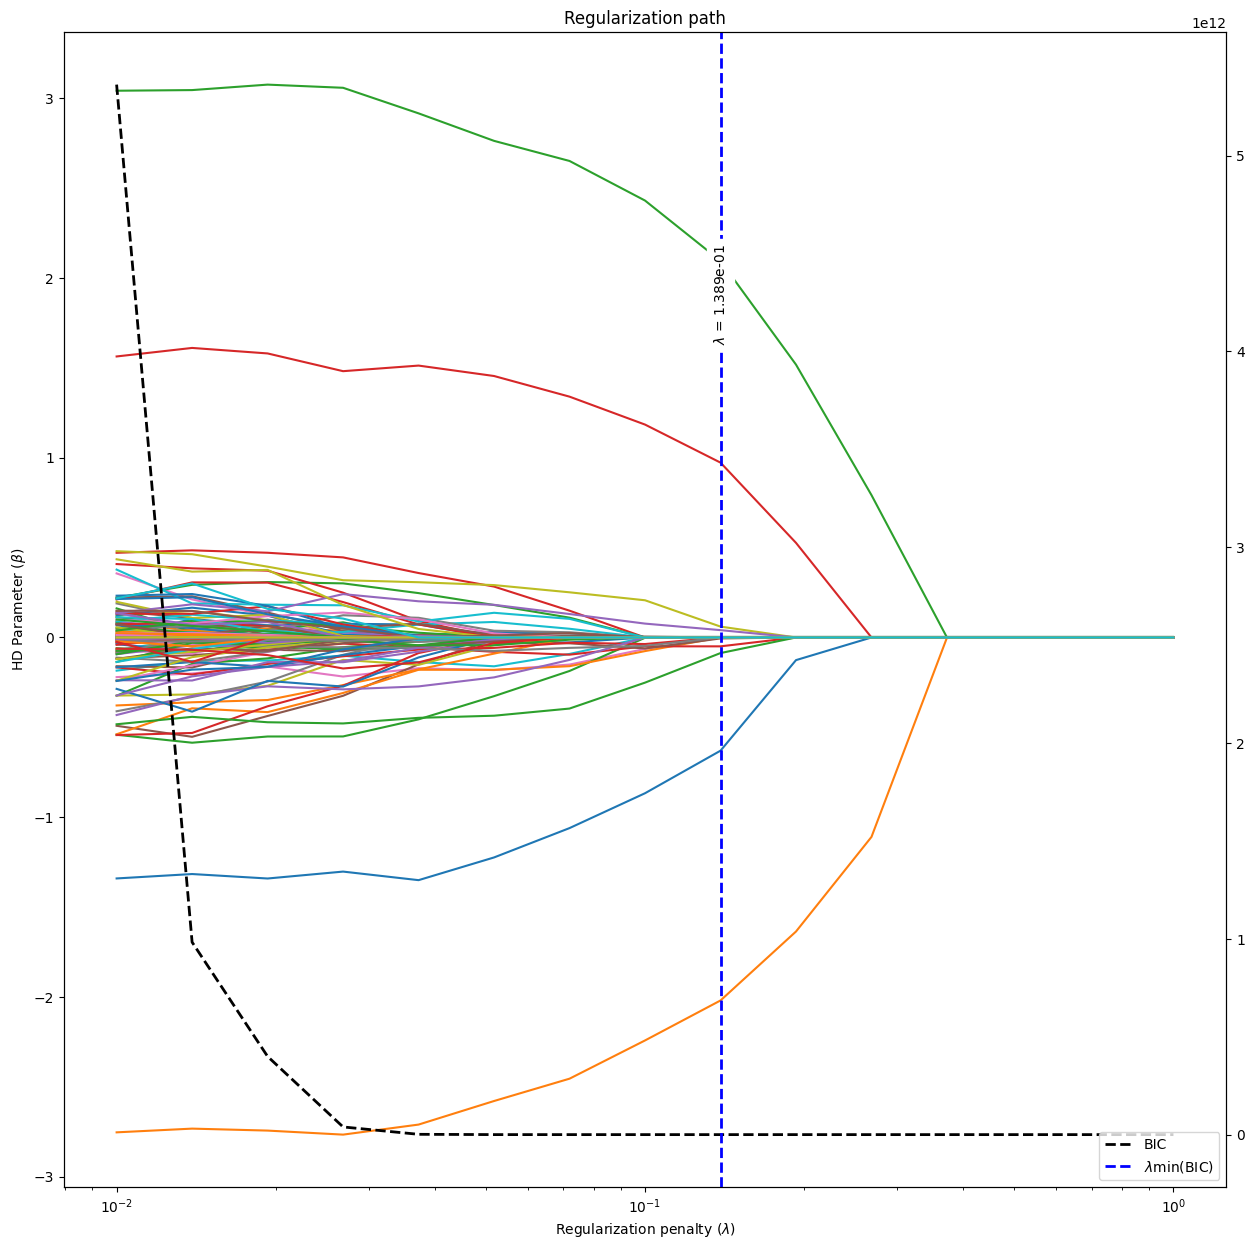

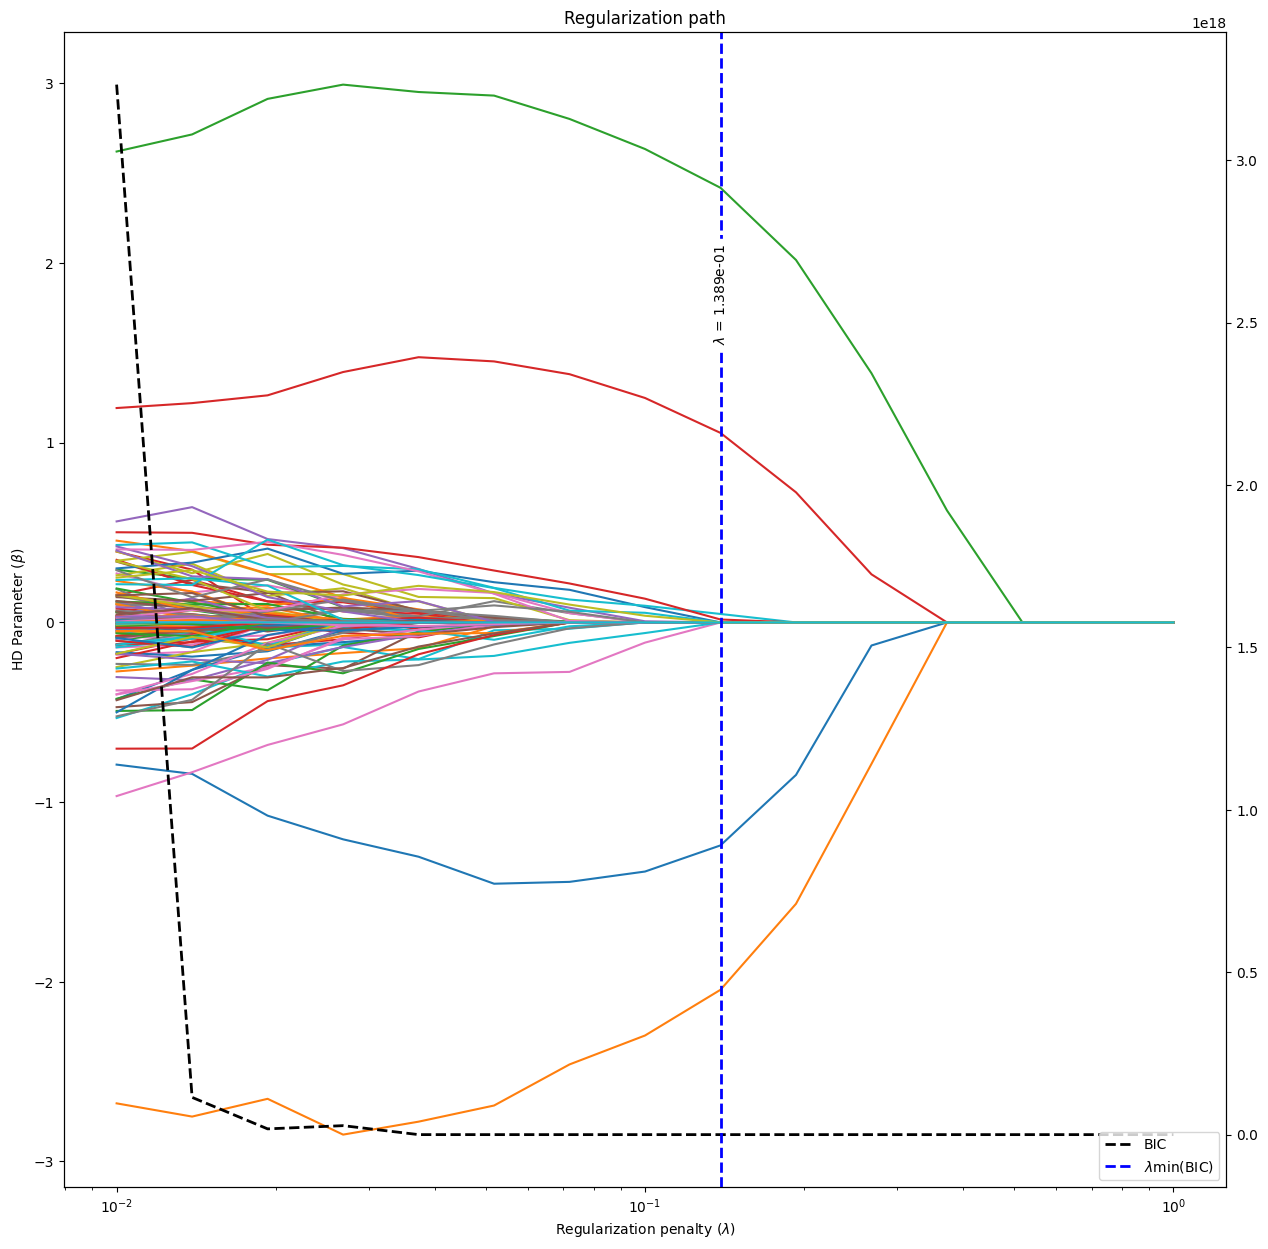

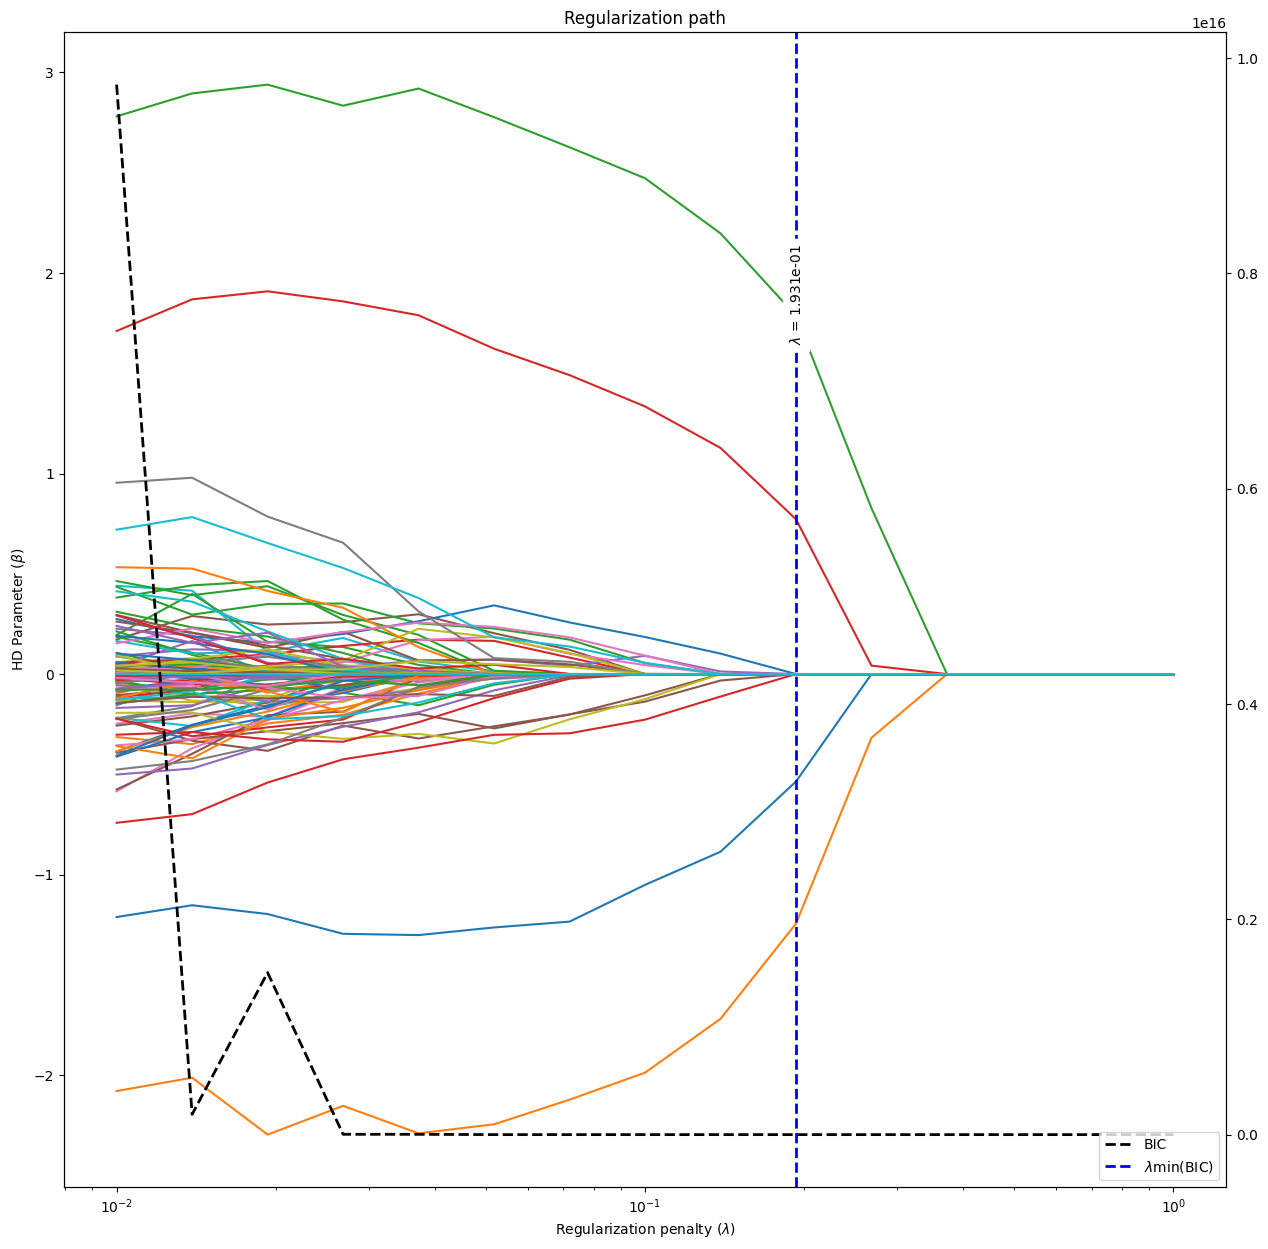

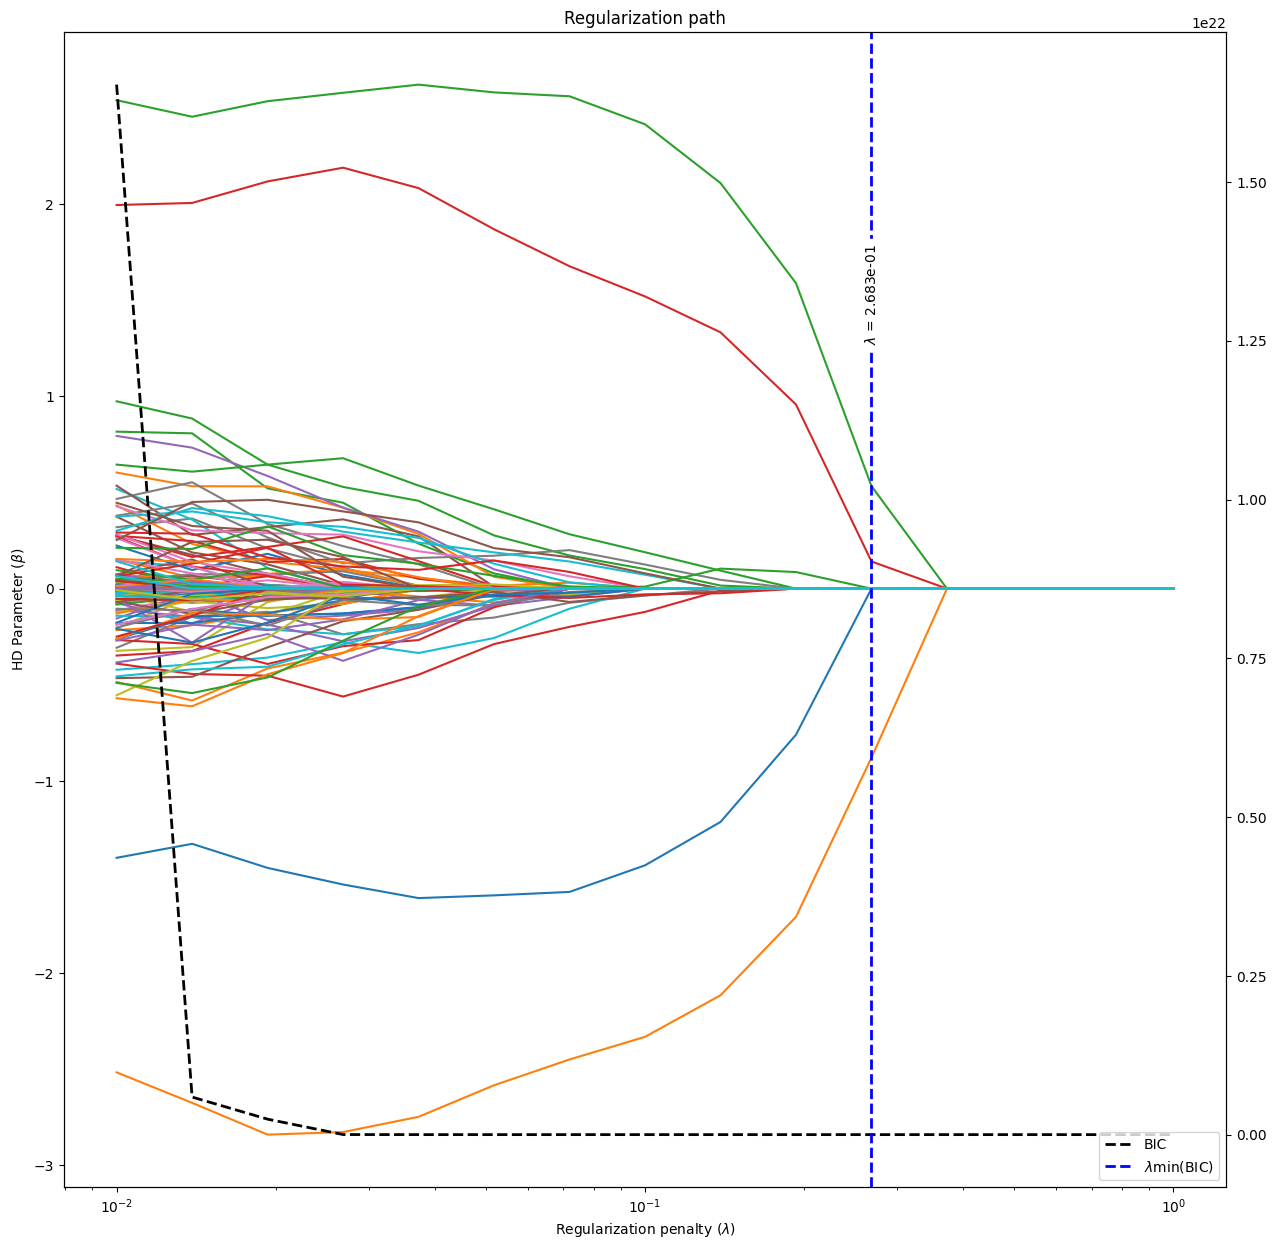

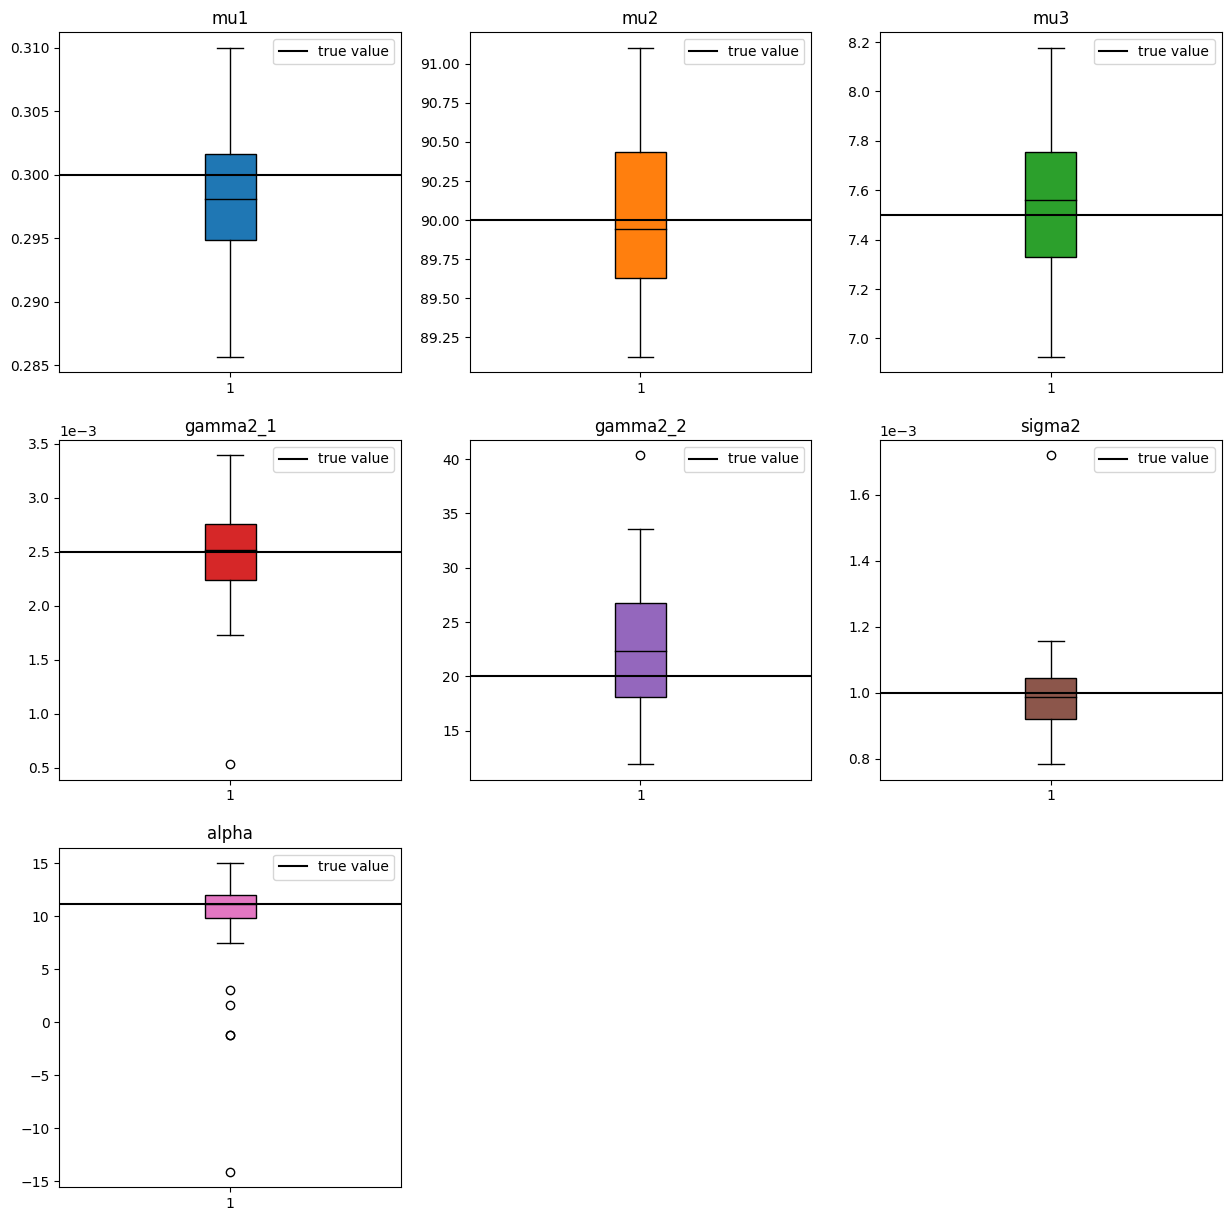

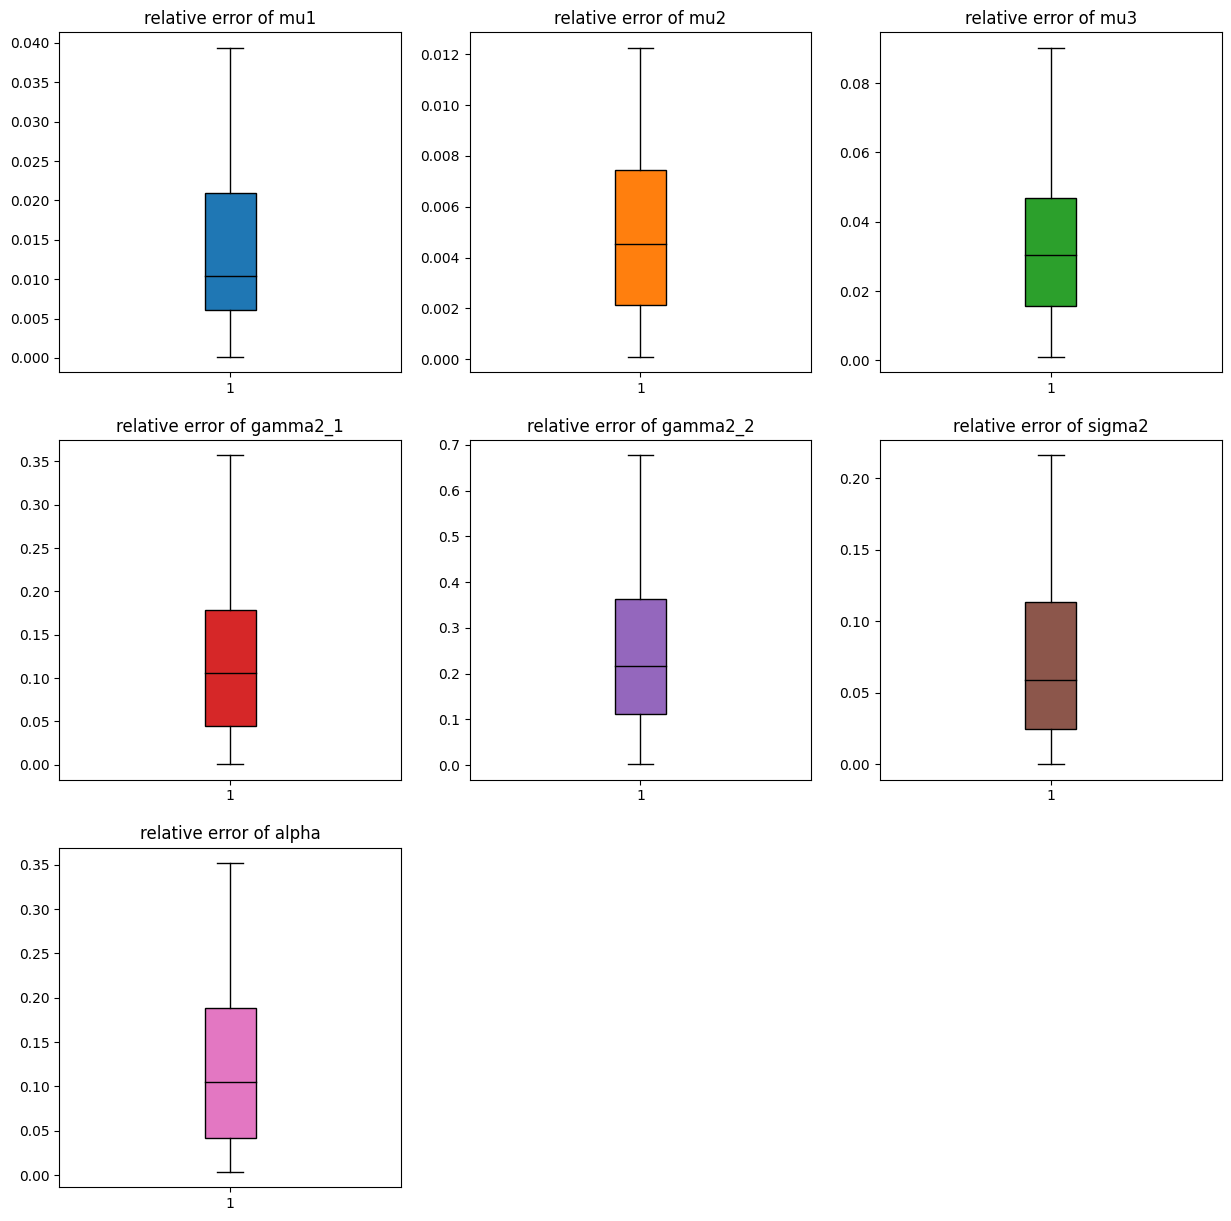

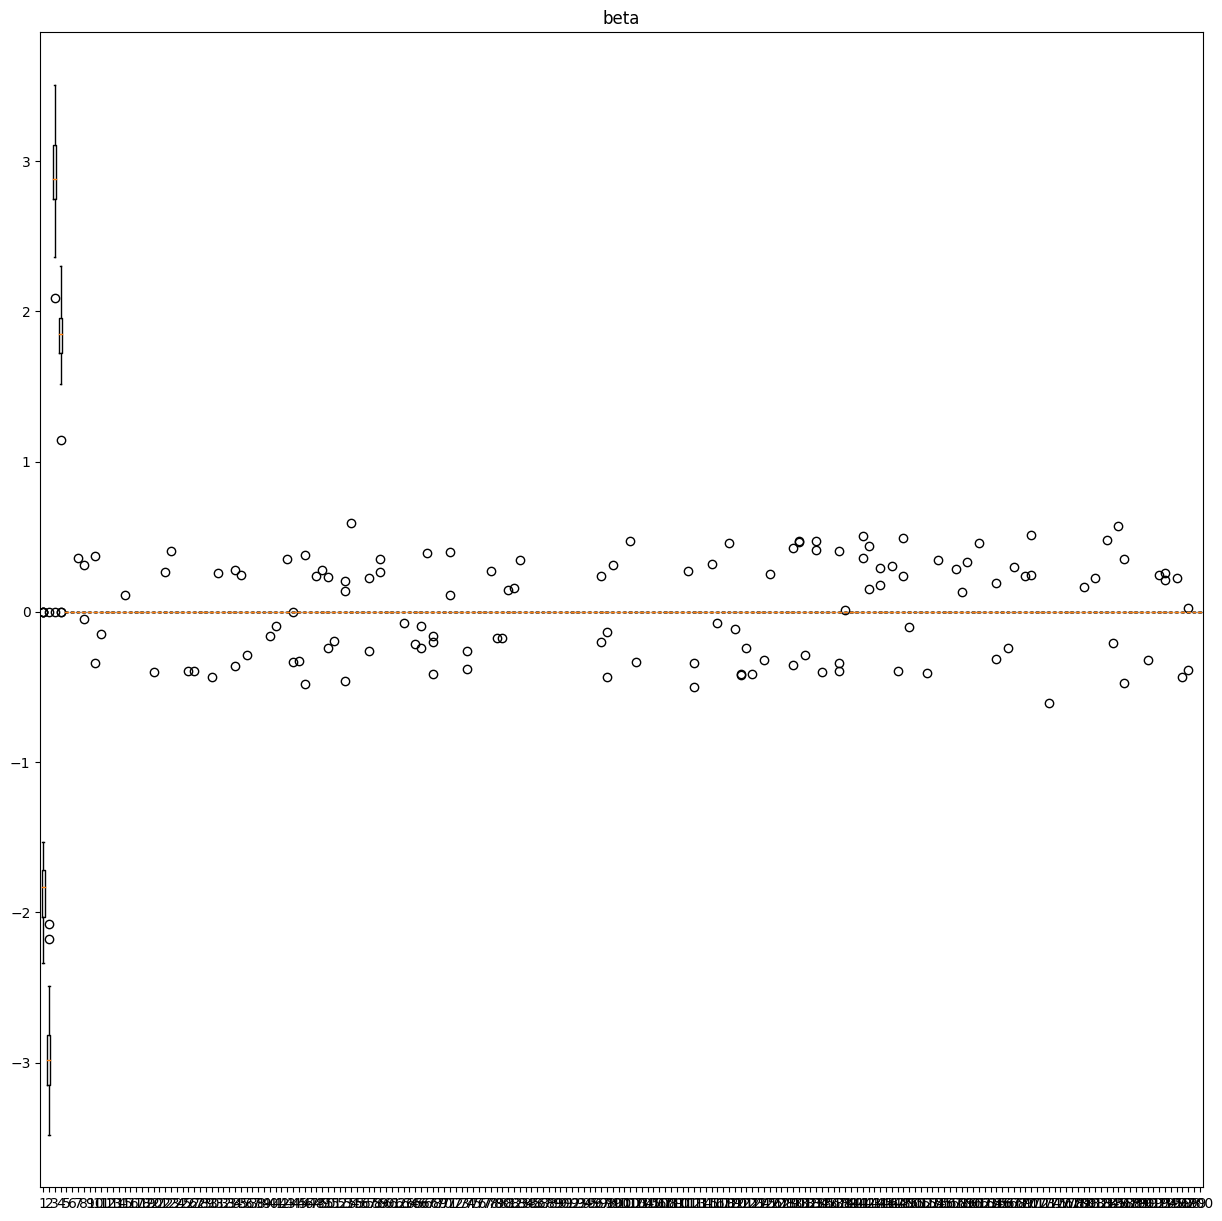

In [1]:
# Create by antoine.caillebotte@inrae.fr

import numpy as np
import pickle

import sdg4varselect.plot as sdgplt

from one_run import (
    get_random_params0,
    params_star_weibull,
    params_star_stack,
    N_IND,
    DIM_COV,
    get_solver,
)

folder = "images"

# 200_50_simple_grad_10_rep
with open("res_multi_run.pkl", "rb") as f:
    data = pickle.load(f)

params_names = data["params_names"]
lbd_set = data["lbd_set"]
theta = np.array(data["theta"])

id = [i for i in range(len(theta)) if not np.isnan(theta[i]).any()]
theta = theta[id]

theta_reg = [data["ltheta_reg"][i] for i in id]
bic = [data["lbic"][i] for i in id]
ebic = [data["lebic"][i] for i in id]

bic = data["lbic"]
id = [i for i in range(len(bic)) if not np.isinf(bic[i]).any()]
theta_reg = [data["ltheta_reg"][i] for i in id]
bic = [data["lbic"][i] for i in id]
ebic = [data["lebic"][i] for i in id]
theta = theta[id]

n_run = theta.shape[0]
print(f"p = {theta.shape[1]-7}, nrun = {n_run}")

# ====================================================== #


for i in [0, 1, 6, 7]:  # range(len(bic)):
    fig, axs = sdgplt.plot_regularization_path(theta_reg[i], lbd_set, bic[i])
    ax, ax_bic = axs

    # z = np.poly1d(np.polyfit(lbd_set, bic[i], deg=4))

    # lbd_set_ext = np.linspace(min(lbd_set), max(lbd_set), num=1000)
    # bic_approx = z(lbd_set_ext)
    # ax_bic.plot(lbd_set_ext, bic_approx, linewidth=4, color="k")

    # id = bic_approx.argmin()
    # ax_bic.axvline(
    #     x=lbd_set_ext[id],
    #     color="k",
    #     linewidth=2,
    #     linestyle="--",
    #     label=r"$\lambda$ approx",
    # )
    # ax_bic.text(
    #     lbd_set_ext[id],
    #     0.8 * bic[i].max() + 0.2 * bic[i].min(),
    #     rf"$\lambda$ = {lbd_set_ext[id]:.3e}",
    #     ha="center",
    #     va="center",
    #     rotation="vertical",
    #     backgroundcolor="white",
    # )

    # ax_ebic = ax.twinx()
    # ax_ebic.plot(lbd_set, ebic[i], color="r", linewidth=2, linestyle="--", label="eBIC")
    # id_min = np.nanargmin(ebic[i])
    # sdgplt.plot_axvline(ax_ebic, lbd_set, ebic[i], id_min, color="g", msg="min(eBIC)")
    # ax_ebic.legend(loc="upper right")

# ====================================================== #
fig = sdgplt.figure()

for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, i], patch_artist=True)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star_stack[i], color="k", label="true value")

    ax.legend()
    ax.set_title(params_names[i])


# ====================================================== #
fig = sdgplt.figure()

for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(
        np.abs(theta[:, i] / params_star_stack[i] - 1),
        patch_artist=True,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.set_title(f"relative error of {params_names[i]}")


# ====================================================== #
fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
beta = theta[:, 7:]
beta_support = beta.sum(axis=0) != 0
num_support = (beta != 0).sum(axis=0)

print(
    f"nombre de fois que chaque composante à était selectionné :\n{num_support/n_run}"
)

id = [i for i in range(len(beta_support))]  # if beta_support[i] and num_support[i] > 5]

#

ax.boxplot(beta[:, id])
ax.set_title("beta")


# ====================================================== #
# fig = sdgplt.figure()
# ax = fig.add_subplot(1, 1, 1)
# ax.boxplot(data["lbd_select"])
# ax.set_title("regularization parameter")

In [2]:
id = [i for i in range(len(beta_support))  if beta_support[i] and num_support[i] > 5]

#

ax.boxplot(beta[:, id])
ax.set_title("beta")


Text(0.5, 1.0, 'beta')

pourcentage de fois que chaque composante à était selectionné :
[0.913 0.978 0.978 0.957 0.    0.    0.022 0.043 0.    0.043 0.022 0.
 0.    0.    0.022 0.    0.    0.    0.    0.022 0.    0.022 0.022 0.
 0.    0.022 0.022 0.    0.    0.022 0.022 0.    0.    0.043 0.022 0.022
 0.    0.    0.    0.022 0.022 0.    0.022 0.043 0.022 0.043 0.    0.022
 0.022 0.043 0.022 0.    0.065 0.022 0.    0.    0.043 0.    0.043 0.
 0.    0.    0.022 0.    0.022 0.043 0.022 0.065 0.    0.    0.043 0.
 0.    0.043 0.    0.    0.    0.022 0.022 0.022 0.022 0.022 0.022 0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.043 0.043 0.022 0.    0.    0.022 0.022 0.    0.    0.    0.    0.
 0.    0.    0.    0.022 0.043 0.    0.    0.022 0.022 0.    0.022 0.022
 0.043 0.022 0.022 0.    0.022 0.022 0.    0.    0.    0.043 0.043 0.022
 0.    0.043 0.022 0.    0.    0.065 0.022 0.    0.    0.043 0.043 0.
 0.043 0.    0.022 0.022 0.043 0.022 0.    0.    0.022 0.    0.022 0.
 0.    0.022 0

Text(0.5, 1.0, 'beta')

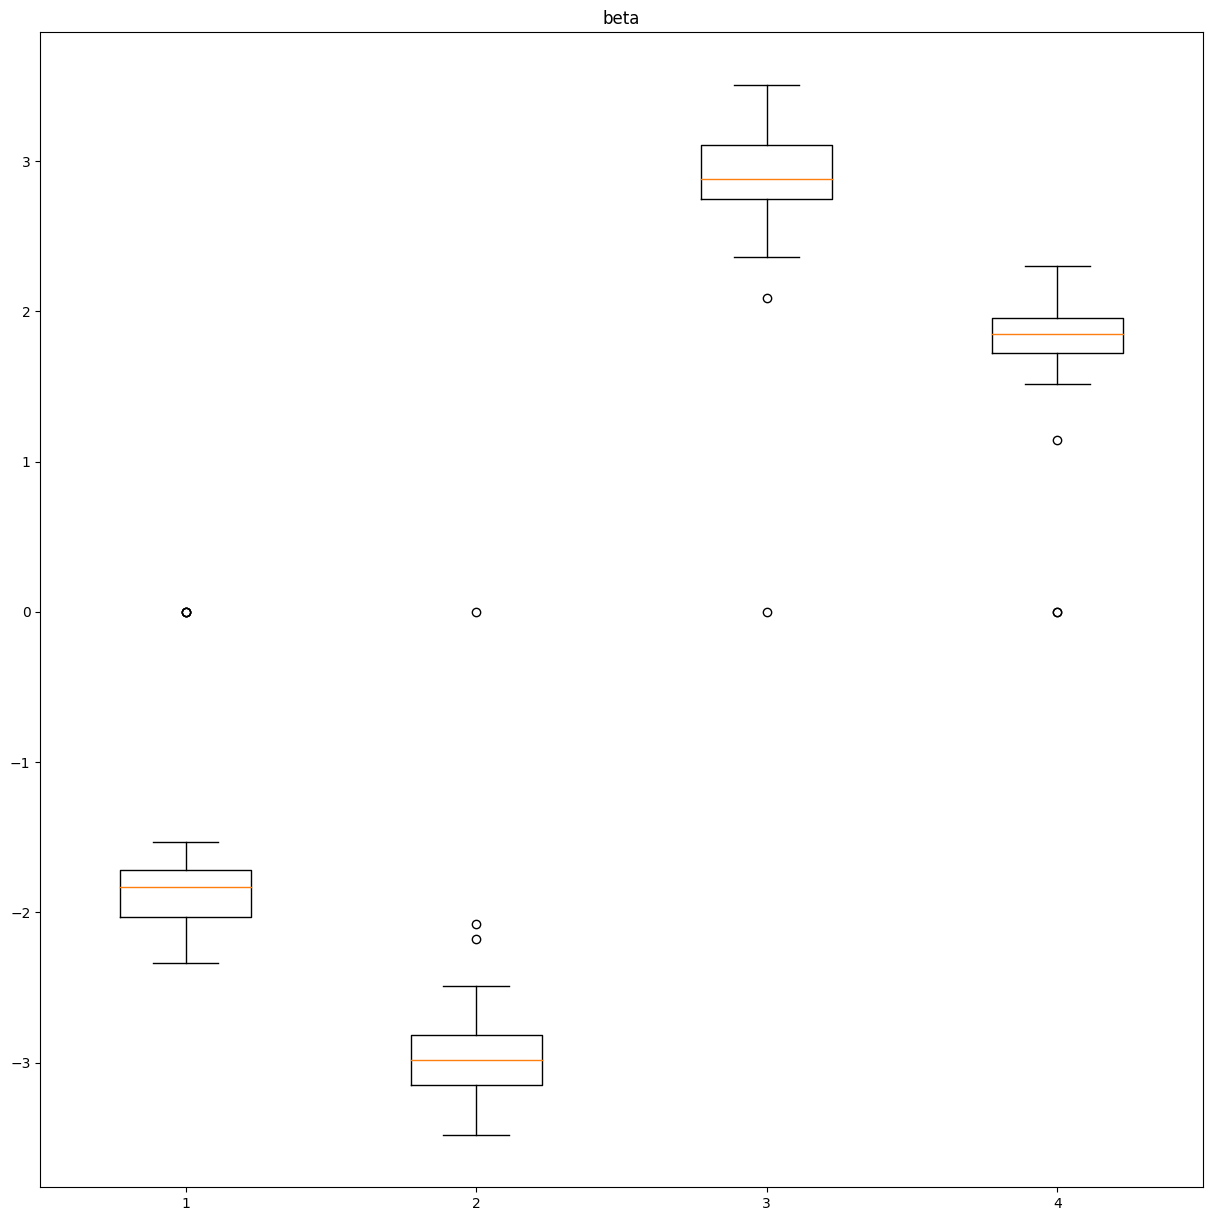

In [3]:
fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
beta = theta[:, 7:]
beta_support = beta.sum(axis=0) != 0
num_support = (beta != 0).sum(axis=0)

print(
    f"pourcentage de fois que chaque composante à était selectionné :\n{num_support/n_run}"
)

id = [i for i in range(len(beta_support))  if beta_support[i] and num_support[i] > 5]

#

ax.boxplot(beta[:, id])
ax.set_title("beta")


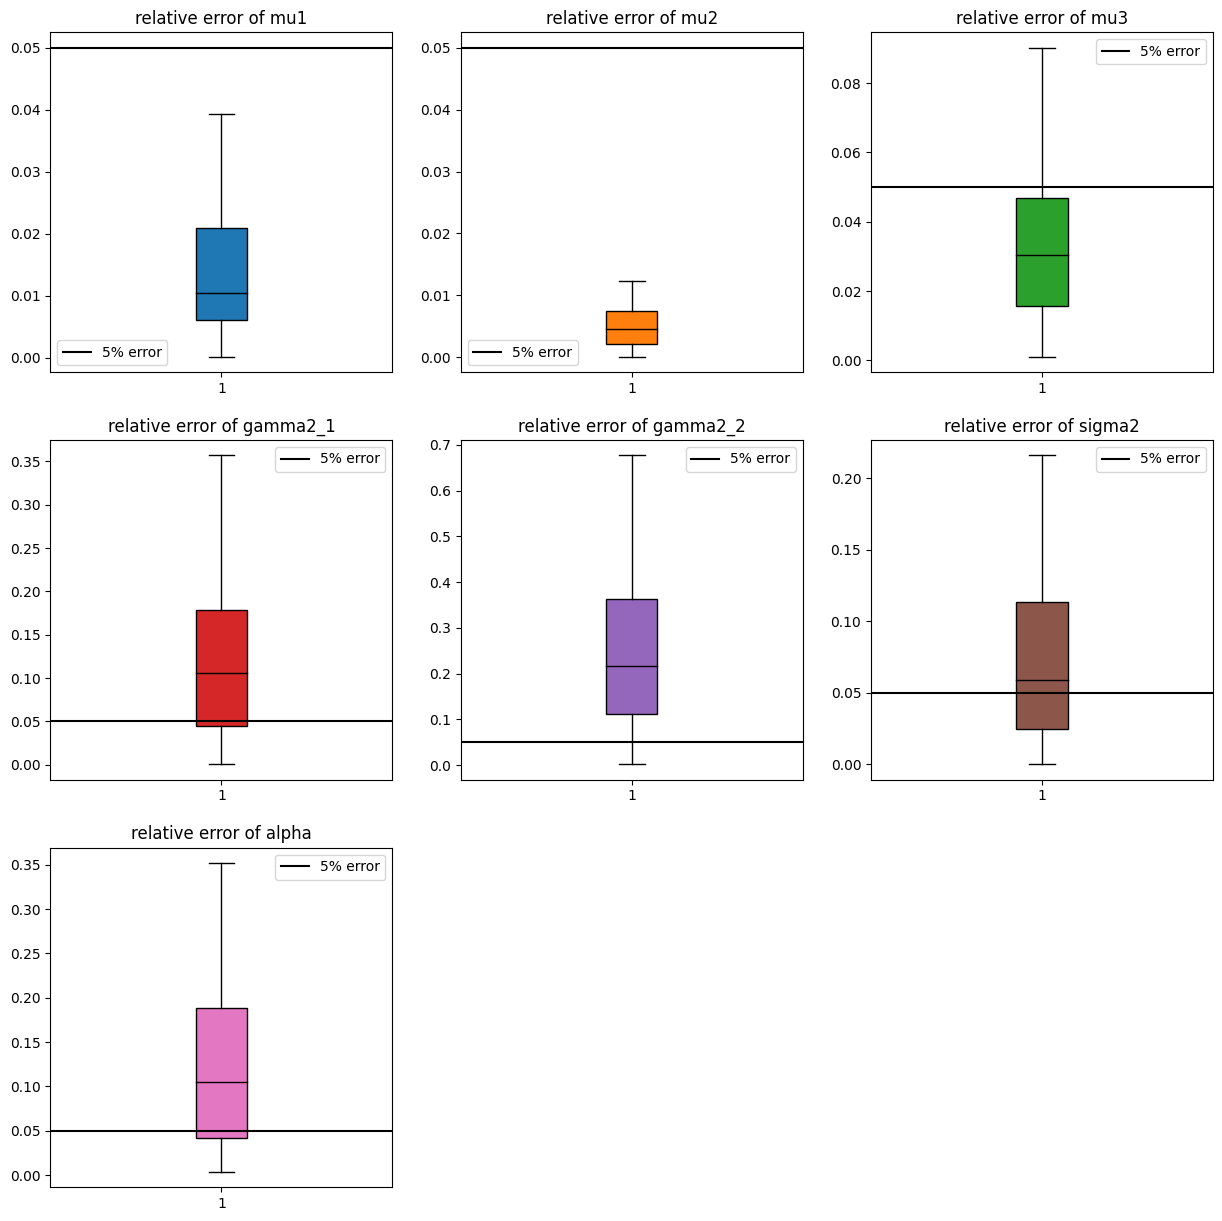

In [4]:
fig = sdgplt.figure()

for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(
        np.abs(theta[:, i] / params_star_stack[i] - 1),
        patch_artist=True,
        showfliers=False,
    )

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=5/100, color="k", label="5% error")

    ax.legend()

    ax.set_title(f"relative error of {params_names[i]}")


In [5]:

import itertools

In [6]:
def f():
    for i in itertools.count():
        if i < 10:
            yield 2*i
        else : 
            return -1
itertools.islice(f(), 15)

In [7]:
def f():
    for i in itertools.count():
        if i < 10:
            yield 2*i
        else : 
            return -1
list(itertools.islice(f(), 15))

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [8]:
def f():
    for i in itertools.count():
        if i < 10:
            yield i
        else : 
            return -1
list(itertools.islice(f(), 15))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
def f():
    for i in itertools.count():
        if i < 10:
            yield np.array([j for j in range(i)]), i
        else : 
            return -1
list(itertools.islice(f(), 15))

[(array([], dtype=float64), 0),
 (array([0]), 1),
 (array([0, 1]), 2),
 (array([0, 1, 2]), 3),
 (array([0, 1, 2, 3]), 4),
 (array([0, 1, 2, 3, 4]), 5),
 (array([0, 1, 2, 3, 4, 5]), 6),
 (array([0, 1, 2, 3, 4, 5, 6]), 7),
 (array([0, 1, 2, 3, 4, 5, 6, 7]), 8),
 (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), 9)]

In [10]:
def f():
    for i in itertools.count():
        if i < 10:
            yield np.array([j for j in range(i)]), i
        else : 
            yield -1
            break
list(itertools.islice(f(), 15))

[(array([], dtype=float64), 0),
 (array([0]), 1),
 (array([0, 1]), 2),
 (array([0, 1, 2]), 3),
 (array([0, 1, 2, 3]), 4),
 (array([0, 1, 2, 3, 4]), 5),
 (array([0, 1, 2, 3, 4, 5]), 6),
 (array([0, 1, 2, 3, 4, 5, 6]), 7),
 (array([0, 1, 2, 3, 4, 5, 6, 7]), 8),
 (array([0, 1, 2, 3, 4, 5, 6, 7, 8]), 9),
 -1]